# Eksplorativna analiza slika

## Struktura skupa podataka

- Ukupno slika: 800
- Broj slika za spring: 200
- Broj slika za summer: 200
- Broj slika za autumn: 200
- Broj slika za winter: 200

- Train: 70%, 140 slika po sezoni
- Test: 15%, 30 slika po sezoni
- Val: 15%, 30 slika po sezoni

## Primeri slika iz svake sezone

S obzirom da ne postoje gotove oznake, svaka slika je ručno klasifikovana na osnovu dosadašnjeg iskustva, pročitane literature i ličnog osećaja. Neke karakterisitike koje su se gledale i na osnovu kojih je moguće odrediti godišnje doba su:

🌸 **Proleće** – rumenija koža, svetlija kosa i svetlije oči  
☀️ **Leto** – bleda koža, svetle oči, ponekad pepeljasta kosa  
🍂 **Jesen** – žućkast ten, često crvenkasta ili riđa kosa  
❄️ **Zima** – tamnija koža, tamna kosa i tamne oči  


In [12]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
import os
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import multiprocessing

import sys
sys.path.append(os.path.join(os.getcwd(), 'src'))
from face_extractor import FaceExtractor


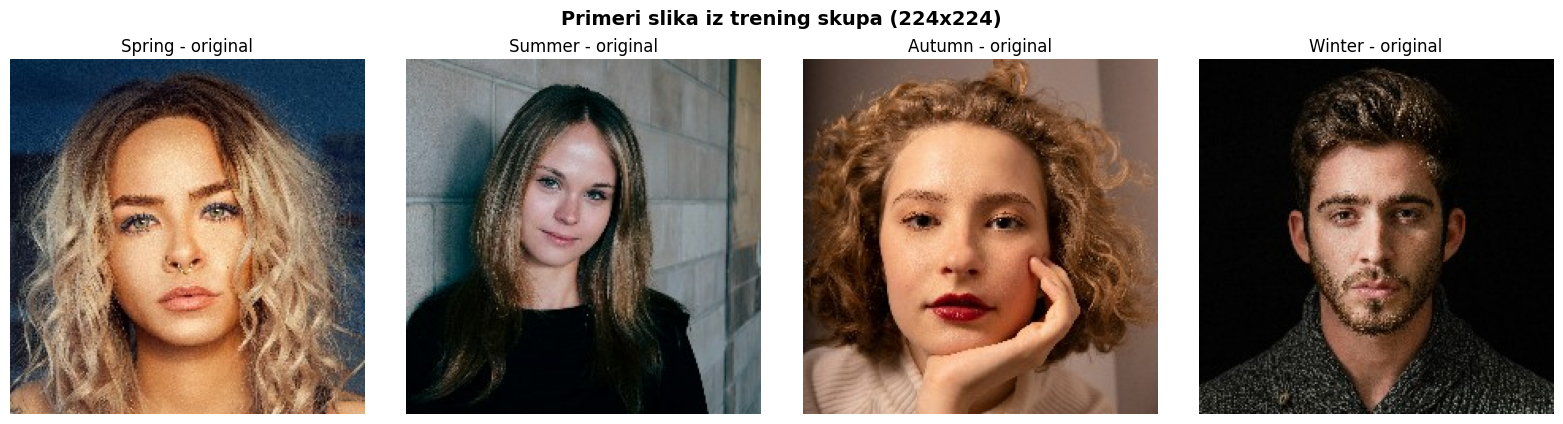

In [13]:

plt.figure(figsize=(16, 8))

for i, sezona in enumerate(['spring', 'summer', 'autumn', 'winter']):

    train_path = f"data/train/{sezona}"
    if os.path.exists(train_path) and len(os.listdir(train_path)) > 0:
        img_name = os.listdir(train_path)[0]
        img_path = f"{train_path}/{img_name}"

        img = cv2.imread(img_path)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(2, 4, i+1)
        plt.imshow(img_rgb)
        plt.title(f'{sezona.capitalize()} - original', fontsize=12)
        plt.axis('off')


plt.suptitle('Primeri slika iz trening skupa (224x224)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## FaceExtractor - Izdvajanje regiona lica

Za potrebe projekta razvijena je klasa `FaceExtractor` koja koristi **MediaPipe Face Mesh** za detekciju 468 ključnih tačaka na licu. Na osnovu ovih tačaka izdvajaju se regioni:

- **Koža lica** - formiranjem ovala lica i uklanjanjem očiju i usana
- **Oči** - pojedinačno levo i desno oko
- **Kosa** - procena regiona iznad čela

### Performanse izdvajanja
- **Koža i oči** - izdvajaju se vrlo precizno
- **Kosa** - izdvajanje je slabije i predstavlja izazov (varijacije u frizurama, bojama, pozadini)

Izdvojeni regioni će se koristiti za treniranje CNN modela kako bi se ispitalo da li specijalizovani regioni (koža, kosa, oči) mogu poboljšati klasifikaciju sezonskih tipova u odnosu na modele trenirane na celoj slici.

FaceExtractor kreiran
 Lice detektovano
   - Piksela kože: 7333
   - Piksela kose: 2230
   - Levo oko: (17, 31, 3)
   - Desno oko: (17, 30, 3)


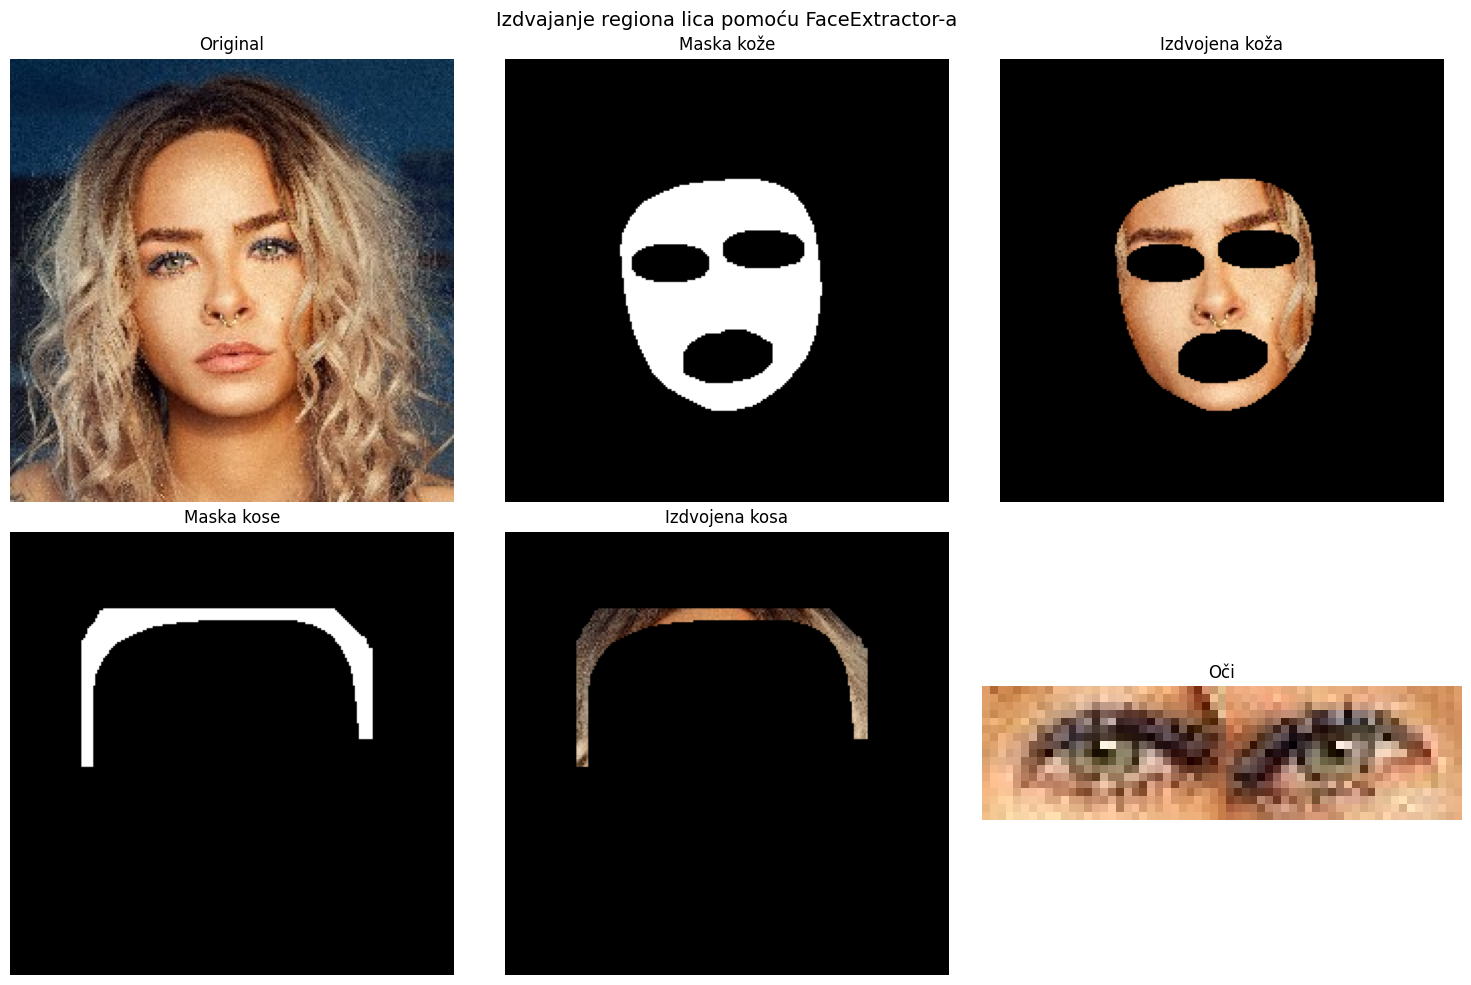

In [14]:
extractor = FaceExtractor()
print("FaceExtractor kreiran")

test_path = "data/train/spring/" + os.listdir("data/train/spring")[0]
result = extractor.extract_features(test_path, visualize=False)

if result:
    print(f" Lice detektovano")
    print(f"   - Piksela kože: {len(result['skin_pixels'])}")
    print(f"   - Piksela kose: {len(result['hair_pixels'])}")
    print(f"   - Levo oko: {result['left_eye'].shape}")
    print(f"   - Desno oko: {result['right_eye'].shape}")

if result:
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))


    axes[0, 0].imshow(cv2.cvtColor(result['original_image'], cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title('Original')
    axes[0, 0].axis('off')


    axes[0, 1].imshow(result['skin_mask'], cmap='gray')
    axes[0, 1].set_title('Maska kože')
    axes[0, 1].axis('off')


    skin_only = cv2.bitwise_and(result['original_image'], result['original_image'], mask=result['skin_mask'])
    axes[0, 2].imshow(cv2.cvtColor(skin_only, cv2.COLOR_BGR2RGB))
    axes[0, 2].set_title('Izdvojena koža')
    axes[0, 2].axis('off')


    axes[1, 0].imshow(result['hair_mask'], cmap='gray')
    axes[1, 0].set_title('Maska kose')
    axes[1, 0].axis('off')


    hair_only = cv2.bitwise_and(result['original_image'], result['original_image'], mask=result['hair_mask'])
    axes[1, 1].imshow(cv2.cvtColor(hair_only, cv2.COLOR_BGR2RGB))
    axes[1, 1].set_title('Izdvojena kosa')
    axes[1, 1].axis('off')


    if result['left_eye'].size > 0 and result['right_eye'].size > 0:
        left = result['left_eye']
        right = result['right_eye']


        target_h = min(left.shape[0], right.shape[0])
        if left.shape[0] != target_h:
            new_w = int(left.shape[1] * target_h / left.shape[0])
            left = cv2.resize(left, (new_w, target_h))
        if right.shape[0] != target_h:
            new_w = int(right.shape[1] * target_h / right.shape[0])
            right = cv2.resize(right, (new_w, target_h))

        combined_eyes = np.hstack([left, right])
        axes[1, 2].imshow(cv2.cvtColor(combined_eyes, cv2.COLOR_BGR2RGB))
        axes[1, 2].set_title('Oči')
        axes[1, 2].axis('off')

    plt.suptitle('Izdvajanje regiona lica pomoću FaceExtractor-a', fontsize=14)
    plt.tight_layout()
    plt.show()

## HSV histogrami po sezoni

U ovoj analizi posmatra se raspodela boja po sezonama korišćenjem **HSV histograma**. Koristi se samo **region kože**, jer predstavlja najrelevantniji deo za određivanje sezonskog kolorita.

- **Hue (H)** – ton boje, odnosno topliji ili hladniji tonovi (warm odnosno cool, pogodno za analizu podtona kože)
- **Saturation (S)** – intenzitet boje, od prigušenih do izraženih tonova (prigušenost boja je karakteristična za summer i spring, dok je izraženost boja karakteristična za autumn i winter)
- **Value (V)** – osvetljenost

Hue i Saturation predstavljaju glavne pokazatelje sezonskog kolorita, dok se Value koristi kao dodatna deskriptivna mera, jer može zavisiti i od uslova osvetljenja i ekspozicije fotografije.

In [15]:
def extract_skin_hsv(result):
    """
    Iz result objekta izdvaja skin_pixels i pretvara ih u HSV.
    Vraća H, S i V nizove.
    """
    if result is None or 'skin_pixels' not in result:
        return None, None, None

    skin_pixels = result['skin_pixels']

    if skin_pixels is None or len(skin_pixels) == 0:
        return None, None, None

    skin_pixels = np.array(skin_pixels, dtype=np.uint8).reshape(-1, 3)

  
    skin_bgr = skin_pixels.reshape(1, -1, 3)
    skin_hsv = cv2.cvtColor(skin_bgr, cv2.COLOR_BGR2HSV).reshape(-1, 3)

    h = skin_hsv[:, 0]
    s = skin_hsv[:, 1]
    v = skin_hsv[:, 2]

    return h, s, v

In [16]:
def collect_skin_hsv_for_season(season_name, max_images=None, sample_pixels=None):
    """
    Prolazi kroz slike jedne sezone, koristi skin_pixels i skuplja H, S, V vrednosti.
    """
    folder = Path(f"data/train/{season_name}")
    image_paths = sorted([p for p in folder.iterdir() if p.is_file()])

    if max_images is not None:
        image_paths = image_paths[:max_images]

    h_all, s_all, v_all = [], [], []
    processed, skipped = 0, 0

    for img_path in tqdm(image_paths, desc=f"HSV {season_name}"):
        try:
            result = extractor.extract_features(str(img_path), visualize=False)
            h, s, v = extract_skin_hsv(result)

            if h is None:
                skipped += 1
                continue

            if sample_pixels is not None and len(h) > sample_pixels:
                idx = np.random.choice(len(h), sample_pixels, replace=False)
                h = h[idx]
                s = s[idx]
                v = v[idx]

            h_all.extend(h)
            s_all.extend(s)
            v_all.extend(v)
            processed += 1

        except Exception as e:
            skipped += 1
            print(f"Greška za {img_path.name}: {e}")

    return {
        "H": np.array(h_all),
        "S": np.array(s_all),
        "V": np.array(v_all),
        "processed": processed,
        "skipped": skipped
    }

In [17]:
skin_hsv_data = {}

for season in ["spring", "summer", "autumn", "winter"]:
    skin_hsv_data[season] = collect_skin_hsv_for_season(
        season_name=season,
        max_images=None,
        sample_pixels=None
    )

print("Gotovo prikupljanje HSV vrednosti za kožu.")


for season in ["spring", "summer", "autumn", "winter"]:
    total = len(list(Path(f"data/train/{season}").glob("*")))
    processed = skin_hsv_data[season]["processed"]

    print(f"{season}: {processed}/{total} images used")

HSV spring:   0%|          | 0/111 [00:00<?, ?it/s]

HSV spring:  41%|████      | 45/111 [00:01<00:01, 42.33it/s]

Nedovoljno piksela za analizu: data\train\spring\058_fleur-kaan-pyrJHb1QTRA-unsplash.jpg


HSV summer:  61%|██████    | 66/108 [00:01<00:00, 54.00it/s]

Nedovoljno piksela za analizu: data\train\summer\093_202335.jpg


...

Nedovoljno piksela za analizu: data\train\winter\022_rita-malcok-vb0XtMgY3Rs-unsplash.jpg


HSV winter:  67%|██████▋   | 72/107 [00:01<00:00, 52.87it/s]

Nedovoljno piksela za analizu: data\train\winter\110_kaboompics_studio-portraits-with-gold-and-silver-earrings-39654.jpg


HSV winter: 100%|██████████| 107/107 [00:01<00:00, 54.94it/s]


Gotovo prikupljanje HSV vrednosti za kožu.
spring: 110/111 images used
summer: 106/108 images used
autumn: 113/114 images used
winter: 105/107 images used


In [18]:
summary_rows = []

for season, values in skin_hsv_data.items():
    summary_rows.append({
        "season": season,
        "processed_images": values["processed"],
        "skipped_images": values["skipped"],
        "num_H_pixels": len(values["H"]),
        "num_S_pixels": len(values["S"]),
        "num_V_pixels": len(values["V"]),
    })

skin_hsv_summary_df = pd.DataFrame(summary_rows)
skin_hsv_summary_df

,season,processed_images,skipped_images,num_H_pixels,num_S_pixels,num_V_pixels
0,spring,110,1,809090,809090,809090
1,summer,106,2,823669,823669,823669
2,autumn,113,1,839045,839045,839045
3,winter,105,2,771504,771504,771504


In [19]:
def plot_single_season_hsv_histograms(season_name, season_data, bins=50):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    channel_info = [
        ("H", "Hue (H)", "Hue"),
        ("S", "Saturation (S)", "Saturation"),
        ("V", "Value (V)", "Value")
    ]

    for ax, (key, title, xlabel) in zip(axes, channel_info):
        ax.hist(
            season_data[key],
            bins=bins,
            density=True,
            alpha=0.7
        )
        ax.set_title(f"{title} - {season_name.capitalize()}", fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Gustina")
        ax.grid(alpha=0.3)

    plt.suptitle(f"HSV histogrami kože - {season_name.capitalize()}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

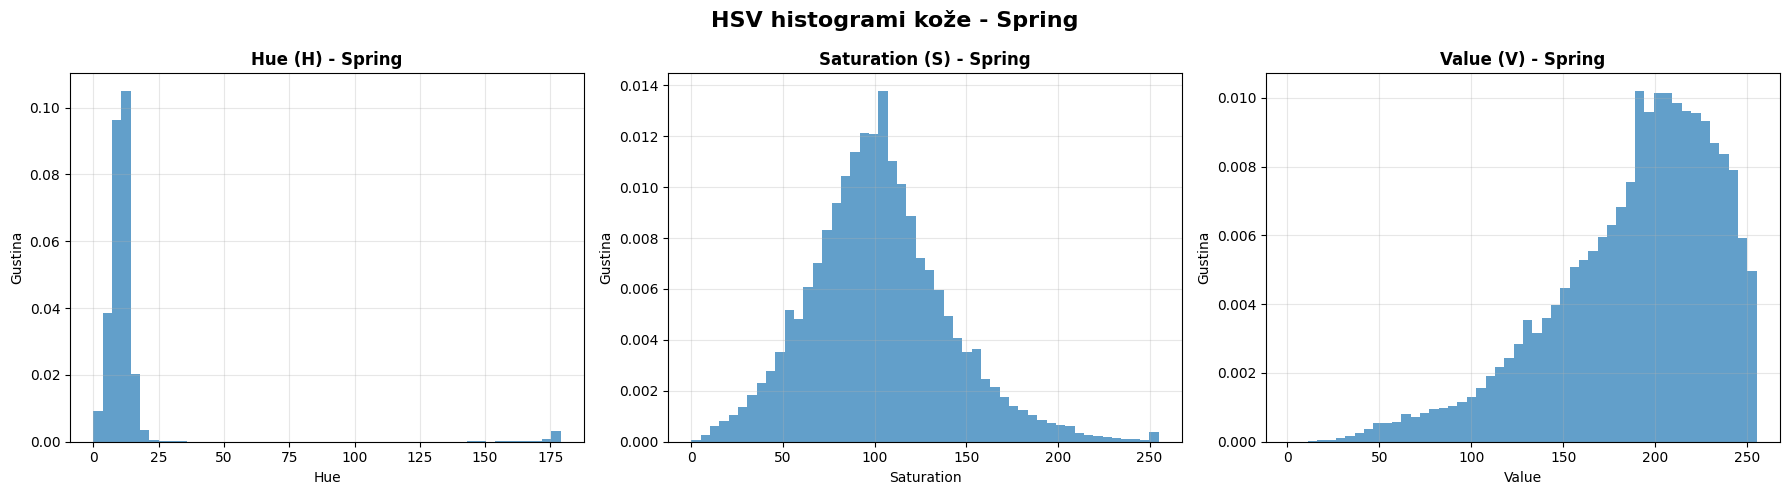

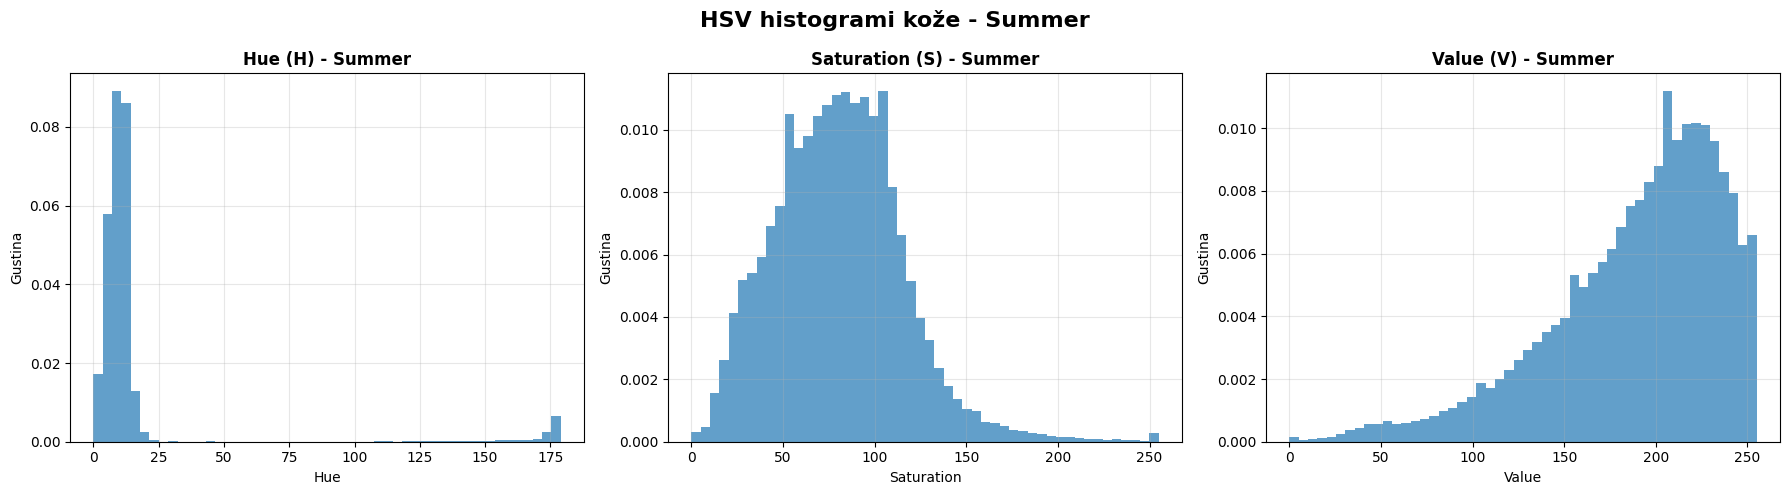

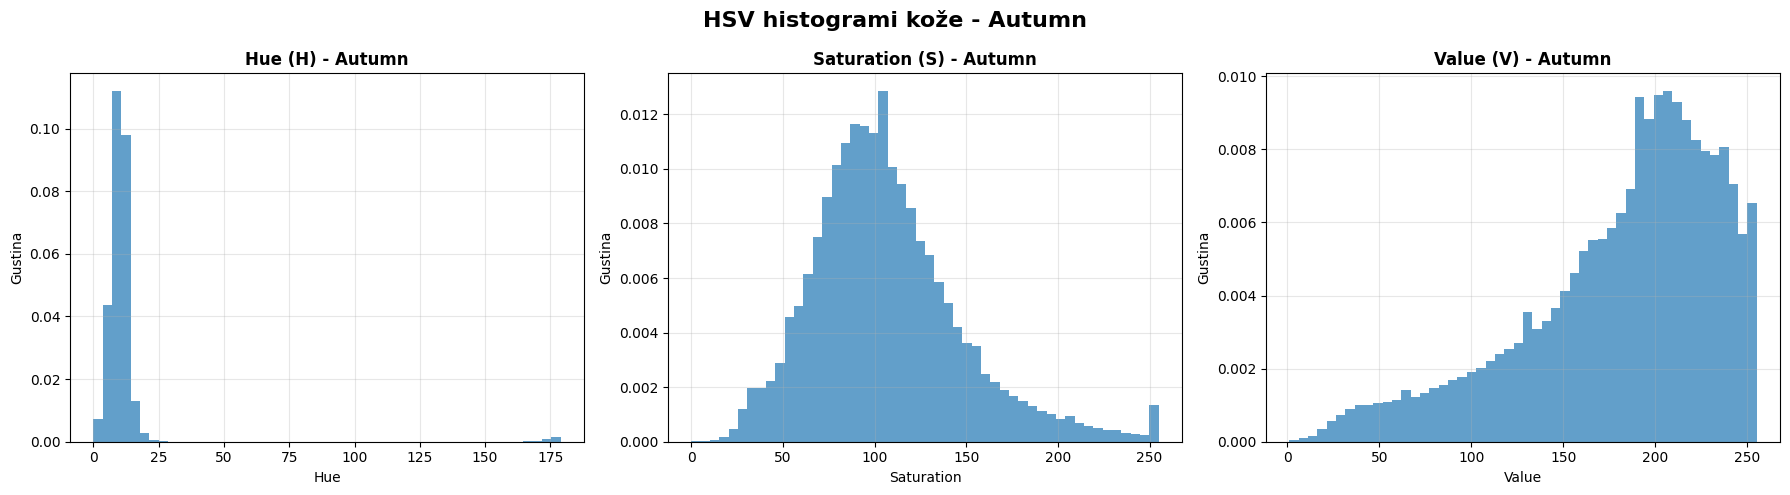

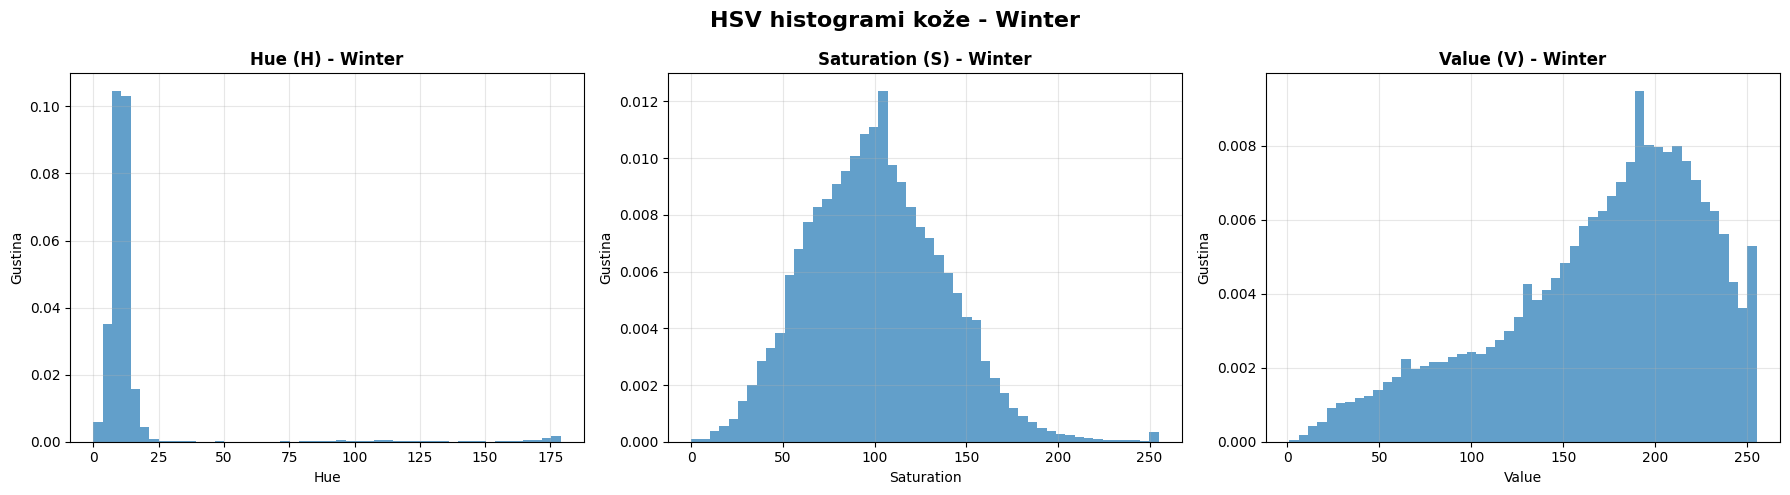

In [20]:
for season in ["spring", "summer", "autumn", "winter"]:
    plot_single_season_hsv_histograms(season, skin_hsv_data[season])

In [21]:
import pandas as pd

rows = []

for season, values in skin_hsv_data.items():
    for h in values["H"]:
        rows.append({"season": season, "channel": "H", "value": h})
    for s in values["S"]:
        rows.append({"season": season, "channel": "S", "value": s})
    for v in values["V"]:
        rows.append({"season": season, "channel": "V", "value": v})

boxplot_df = pd.DataFrame(rows)
boxplot_df.head()

,season,channel,value
0,spring,H,15
1,spring,H,15
2,spring,H,15
3,spring,H,15
4,spring,H,15


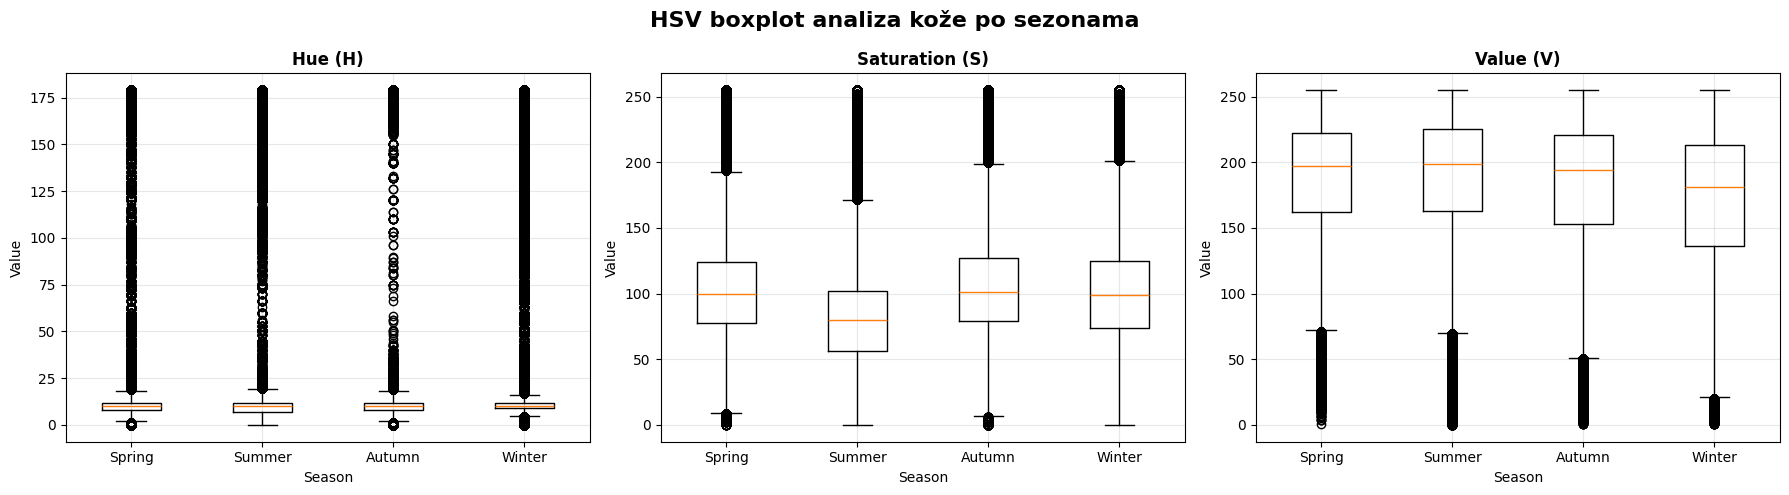

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = ["H", "S", "V"]
titles = ["Hue (H)", "Saturation (S)", "Value (V)"]

for ax, ch, title in zip(axes, channels, titles):
    data_to_plot = [
        boxplot_df[(boxplot_df["season"] == season) & (boxplot_df["channel"] == ch)]["value"]
        for season in ["spring", "summer", "autumn", "winter"]
    ]

    ax.boxplot(data_to_plot, labels=["Spring", "Summer", "Autumn", "Winter"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Season")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

plt.suptitle("HSV boxplot analiza kože po sezonama", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
mean_rows = []

for season, values in skin_hsv_data.items():
    mean_rows.append({
        "season": season,
        "H_mean": values["H"].mean(),
        "S_mean": values["S"].mean(),
        "V_mean": values["V"].mean()
    })

mean_df = pd.DataFrame(mean_rows)
mean_df

,season,H_mean,S_mean,V_mean
0,spring,13.229481,102.443409,188.237121
1,summer,16.718826,80.447246,188.818661
2,autumn,11.376938,106.509900,180.816599
3,winter,14.532269,100.818924,169.471995


## Analiza HSV komponenti na regionu kože

U cilju ispitivanja razlika između sezonskih kategorija (Spring, Summer, Autumn, Winter), izvršena je analiza distribucija HSV komponenti (Hue, Saturation, Value) nad izdvojenim pikselima kože. Ovakav pristup eliminiše uticaj pozadine, odeće i drugih spoljašnjih faktora, fokusirajući se isključivo na relevantne karakteristike tona kože.

### Analiza Hue (H) komponente

Hue komponenta opisuje ton boje, odnosno pomeranje ka toplijim ili hladnijim nijansama. Na osnovu dobijenih rezultata, uočava se da Summer kategorija ima najveću srednju vrednost Hue komponente, što ukazuje na pomeranje ka hladnijim tonovima. S druge strane, Autumn i Spring pokazuju niže vrednosti, što je u skladu sa toplijim karakteristikama ovih sezona. Winter zauzima međupoložaj između toplijih i hladnijih tonova.

Iako se distribucije značajno preklapaju, razlike u srednjim vrednostima i raspodeli potvrđuju postojanje suptilnih pomeranja između klasa.

### Analiza Saturation (S) komponente

Saturation komponenta predstavlja intenzitet boje, odnosno razlikovanje između prigušenih i izraženih tonova. Rezultati pokazuju da Summer kategorija ima značajno niže vrednosti zasićenosti, što odgovara njenoj karakteristici mekših i prigušenijih tonova. Nasuprot tome, Autumn ima najviše vrednosti, što ukazuje na bogatije i intenzivnije nijanse.

Spring i Winter imaju srednje do više vrednosti zasićenosti, pri čemu se njihove distribucije delimično preklapaju. Saturation komponenta se pokazala kao najizraženiji faktor diferencijacije između sezonskih kategorija.

### Analiza Value (V) komponente

Value komponenta opisuje osvetljenost, odnosno svetlinu tona. Uočava se da Spring i Summer imaju više prosečne vrednosti, što ukazuje na svetlije tonove, dok Autumn i naročito Winter pokazuju niže vrednosti, što odgovara tamnijim i kontrastnijim karakteristikama.

Međutim, treba naglasiti da Value komponenta može biti pod značajnim uticajem spoljašnjih faktora kao što su osvetljenje i ekspozicija fotografije, te se njeni rezultati tumače kao dopunski, a ne primarni pokazatelj.

### Zaključak

Analiza HSV komponenti pokazuje da se sezonske kategorije ne razlikuju kroz jasno razdvojene opsege vrednosti, već kroz suptilne pomake u distribucijama i srednjim vrednostima. Najizraženija razlika uočena je u Saturation komponenti, dok Hue i Value dodatno doprinose razumevanju razlika između klasa.

Ovi rezultati ukazuju na to da je problem klasifikacije sezonskog kolorita fine granularnosti, gde razlike nisu diskretne već kontinuirane. Zbog toga je primena modela dubokog učenja, kao što su konvolucione neuronske mreže, opravdana, jer omogućava hvatanje kompleksnih i suptilnih obrazaca u podacima.

## Analiza HSV komponenti na regionu očiju

Pored analize kože, izvršena je i analiza HSV komponenti nad regionom očiju, kako bi se ispitalo da li boja očiju pokazuje dodatne razlike između sezonskih kategorija.

Posmatrane su sledeće komponente:

- **Hue (H)** – ton boje, odnosno pomeranje ka toplijim ili hladnijim nijansama
- **Saturation (S)** – intenzitet boje, odnosno prigušenost ili izraženost tonova
- **Value (V)** – osvetljenost odnosno svetlina

Za razliku od kože, region očiju je manji i osetljiviji na refleksije, senke i kvalitet fotografije, pa se rezultati ove analize posmatraju kao dopunski pokazatelj u okviru klasifikacije sezonskog kolorita.

In [24]:
def get_eye_pixels_from_result(result):
    
    if result is None:
        return None

    eye_parts = []

    for key in ["left_eye", "right_eye"]:
        if key in result and result[key] is not None:
            eye_img = np.array(result[key], dtype=np.uint8)

            if eye_img.ndim == 3 and eye_img.shape[2] == 3:
                eye_pixels = eye_img.reshape(-1, 3)

            
                eye_pixels = eye_pixels[np.any(eye_pixels > 0, axis=1)]

                if len(eye_pixels) > 0:
                    eye_parts.append(eye_pixels)

    if len(eye_parts) == 0:
        return None

    return np.vstack(eye_parts)

In [25]:
def extract_eye_hsv(result):

    eye_pixels = get_eye_pixels_from_result(result)

    if eye_pixels is None or len(eye_pixels) == 0:
        return None, None, None

    eye_pixels = np.array(eye_pixels, dtype=np.uint8).reshape(-1, 3)

    eye_bgr = eye_pixels.reshape(1, -1, 3)
    eye_hsv = cv2.cvtColor(eye_bgr, cv2.COLOR_BGR2HSV).reshape(-1, 3)

    h = eye_hsv[:, 0]
    s = eye_hsv[:, 1]
    v = eye_hsv[:, 2]

    return h, s, v

In [26]:
sample_path = "data/train/spring/" + sorted([p.name for p in Path("data/train/spring").iterdir() if p.is_file()])[0]

result = extractor.extract_features(sample_path, visualize=False)
h, s, v = extract_eye_hsv(result)

print("H:", None if h is None else h.shape)
print("S:", None if s is None else s.shape)
print("V:", None if v is None else v.shape)

H: (1037,)
S: (1037,)
V: (1037,)


In [27]:
def collect_eye_hsv_for_season(season_name, max_images=None, sample_pixels=None):
    folder = Path(f"data/train/{season_name}")
    image_paths = sorted([p for p in folder.iterdir() if p.is_file()])

    if max_images is not None:
        image_paths = image_paths[:max_images]

    h_all, s_all, v_all = [], [], []
    processed, skipped = 0, 0

    for img_path in tqdm(image_paths, desc=f"Eye HSV {season_name}"):
        try:
            result = extractor.extract_features(str(img_path), visualize=False)
            h, s, v = extract_eye_hsv(result)

            if h is None or len(h) == 0:
                skipped += 1
                continue

            if sample_pixels is not None and len(h) > sample_pixels:
                idx = np.random.choice(len(h), sample_pixels, replace=False)
                h = h[idx]
                s = s[idx]
                v = v[idx]

            h_all.extend(h)
            s_all.extend(s)
            v_all.extend(v)
            processed += 1

        except Exception as e:
            skipped += 1
            print(f"Greška za {img_path.name}: {e}")

    return {
        "H": np.array(h_all),
        "S": np.array(s_all),
        "V": np.array(v_all),
        "processed": processed,
        "skipped": skipped
    }

In [28]:
eye_hsv_data = {}

for season in ["spring", "summer", "autumn", "winter"]:
    eye_hsv_data[season] = collect_eye_hsv_for_season(
        season_name=season,
        max_images=None,
        sample_pixels=None
    )

print("Gotovo prikupljanje HSV vrednosti za oči.")

for season in ["spring", "summer", "autumn", "winter"]:
    total = len(list(Path(f"data/train/{season}").glob("*")))
    processed = eye_hsv_data[season]["processed"]

    print(f"{season}: {processed}/{total} images used")

Eye HSV spring:  42%|████▏     | 47/111 [00:00<00:01, 59.31it/s]

Nedovoljno piksela za analizu: data\train\spring\058_fleur-kaan-pyrJHb1QTRA-unsplash.jpg


Eye HSV summer:  56%|█████▋    | 61/108 [00:01<00:00, 57.58it/s]

Nedovoljno piksela za analizu: data\train\summer\093_202335.jpg


Eye HSV summer:  97%|█████████▋| 105/108 [00:02<00:00, 38.19it/s]

...

Nedovoljno piksela za analizu: data\train\winter\022_rita-malcok-vb0XtMgY3Rs-unsplash.jpg


Eye HSV winter:  64%|██████▍   | 69/107 [00:01<00:00, 59.76it/s]

Nedovoljno piksela za analizu: data\train\winter\110_kaboompics_studio-portraits-with-gold-and-silver-earrings-39654.jpg


Eye HSV winter: 100%|██████████| 107/107 [00:01<00:00, 59.03it/s]

Gotovo prikupljanje HSV vrednosti za oči.
spring: 110/111 images used
summer: 106/108 images used
autumn: 113/114 images used
winter: 105/107 images used


In [29]:
def plot_single_season_eye_hsv_histograms(season_name, season_data, bins=40):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    channel_info = [
        ("H", "Hue (H)", "Hue"),
        ("S", "Saturation (S)", "Saturation"),
        ("V", "Value (V)", "Value")
    ]

    for ax, (key, title, xlabel) in zip(axes, channel_info):
        if len(season_data[key]) == 0:
            ax.set_title(f"{title} - {season_name.capitalize()}", fontweight="bold")
            ax.text(0.5, 0.5, "Nema podataka", ha="center", va="center", transform=ax.transAxes)
            ax.set_xlabel(xlabel)
            ax.set_ylabel("Gustina")
            ax.grid(alpha=0.3)
            continue

        ax.hist(
            season_data[key],
            bins=bins,
            density=True,
            alpha=0.7
        )
        ax.set_title(f"{title} - {season_name.capitalize()}", fontweight="bold")
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Gustina")
        ax.grid(alpha=0.3)

    plt.suptitle(f"HSV histogrami očiju - {season_name.capitalize()}", fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()

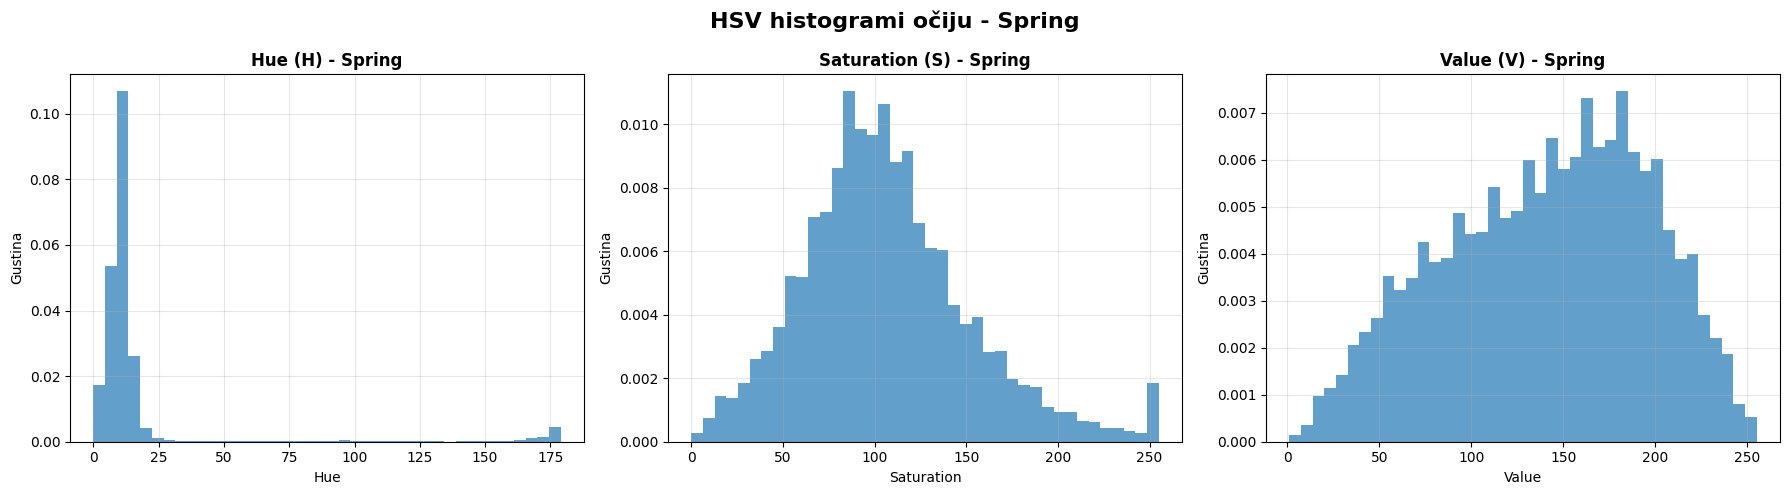

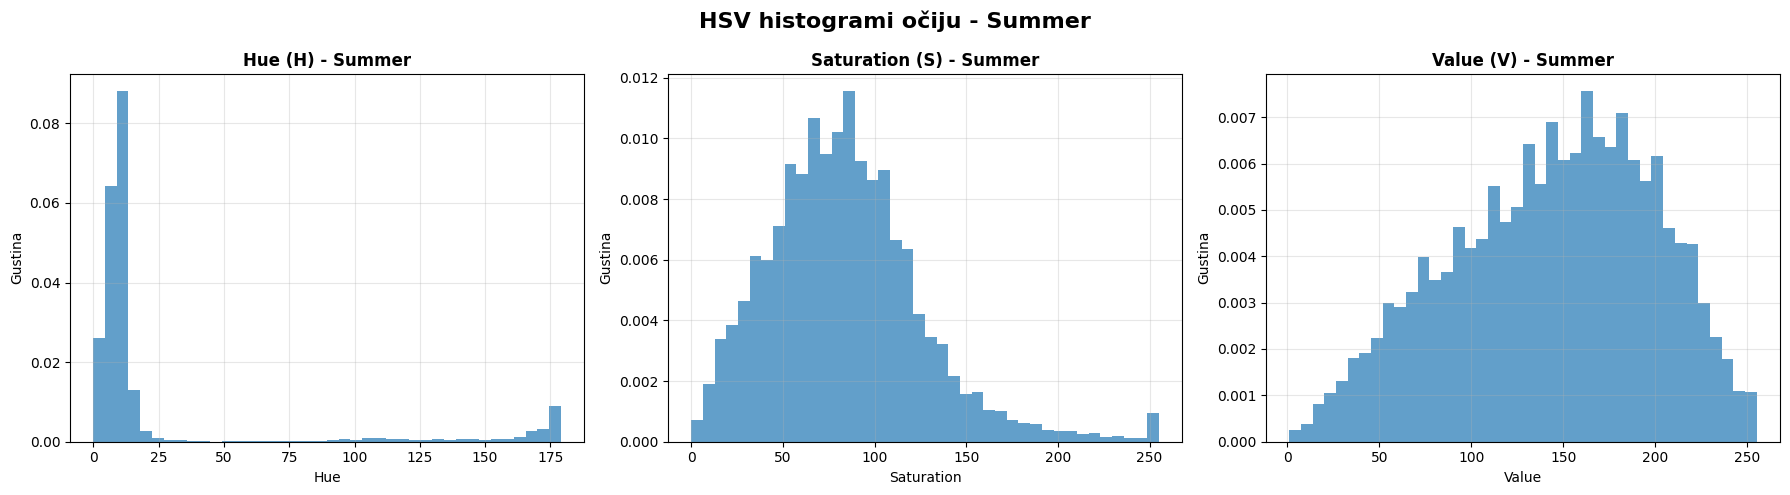

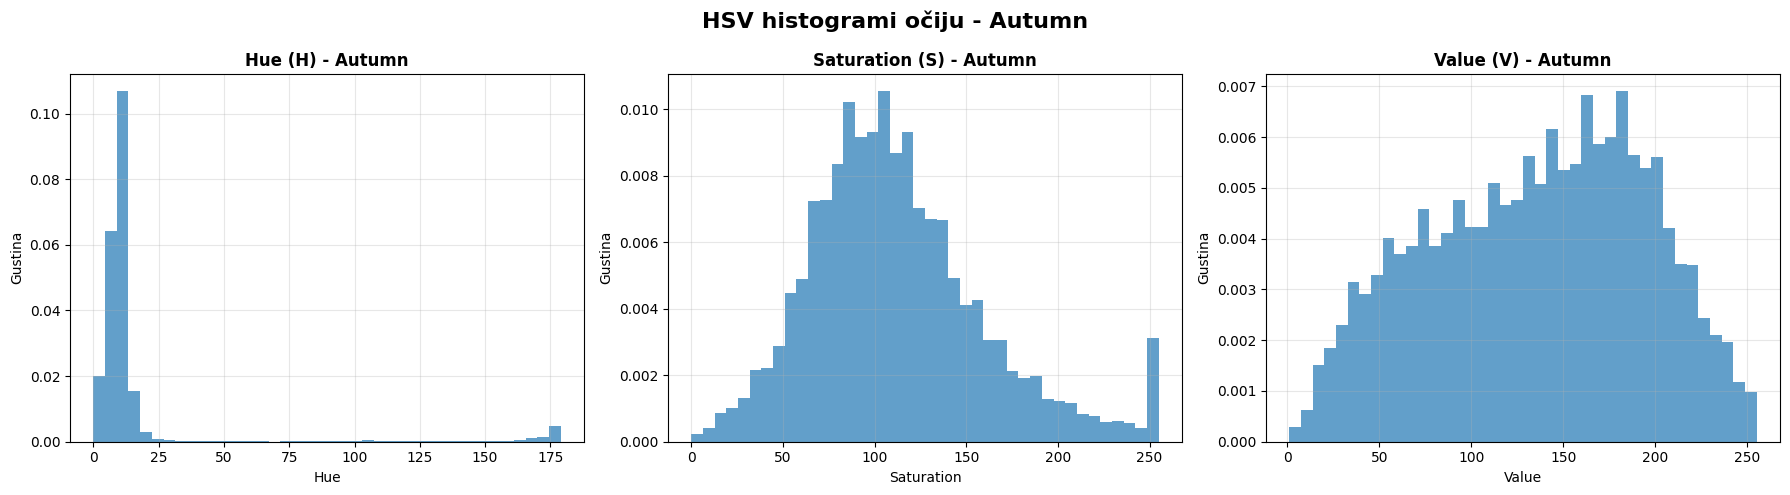

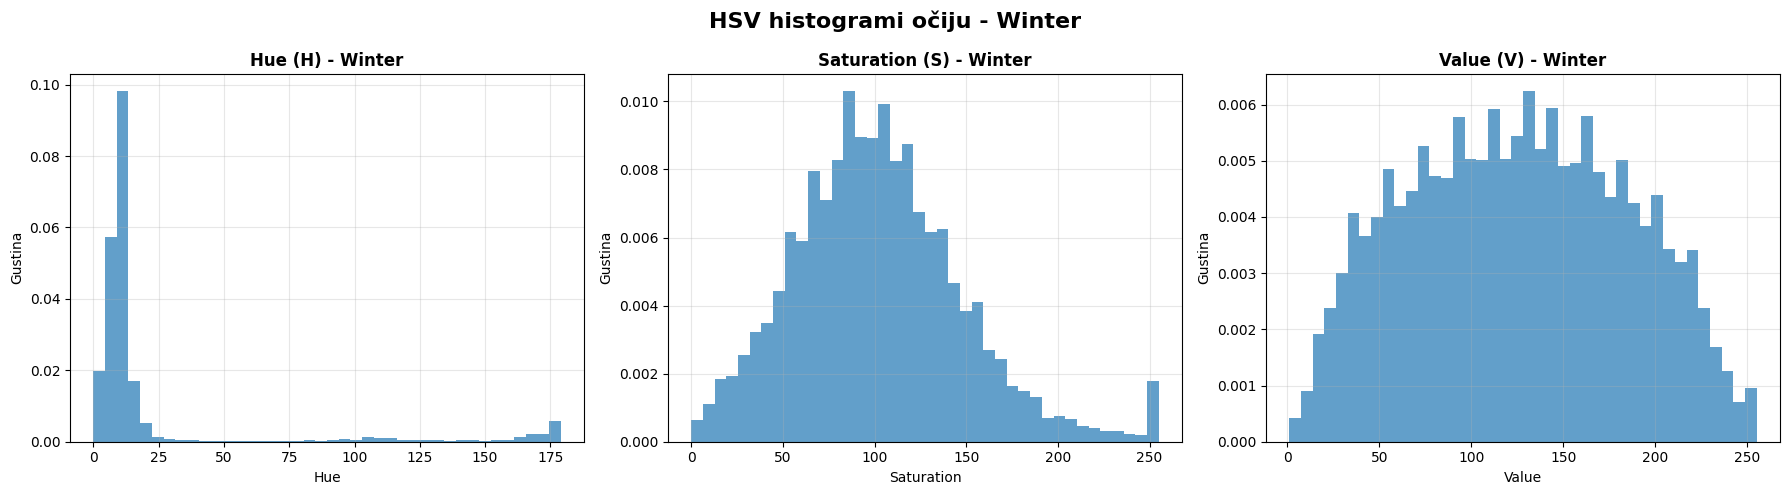

In [30]:
for season in ["spring", "summer", "autumn", "winter"]:
    plot_single_season_eye_hsv_histograms(season, eye_hsv_data[season])

In [31]:
eye_boxplot_rows = []

for season, values in eye_hsv_data.items():
    for h in values["H"]:
        eye_boxplot_rows.append({"season": season, "channel": "H", "value": h})
    for s in values["S"]:
        eye_boxplot_rows.append({"season": season, "channel": "S", "value": s})
    for v in values["V"]:
        eye_boxplot_rows.append({"season": season, "channel": "V", "value": v})

eye_boxplot_df = pd.DataFrame(eye_boxplot_rows)
eye_boxplot_df.head()

,season,channel,value
0,spring,H,13
1,spring,H,13
2,spring,H,13
3,spring,H,13
4,spring,H,13


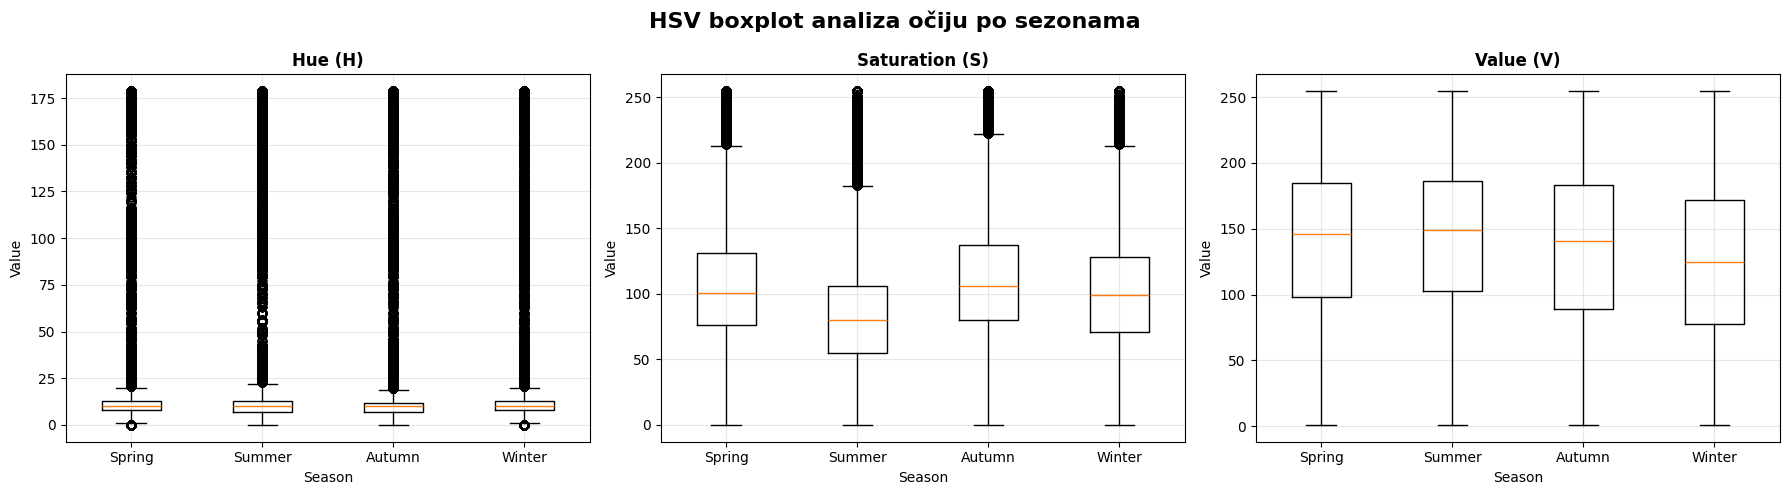

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

channels = ["H", "S", "V"]
titles = ["Hue (H)", "Saturation (S)", "Value (V)"]

for ax, ch, title in zip(axes, channels, titles):
    data_to_plot = [
        eye_boxplot_df[
            (eye_boxplot_df["season"] == season) &
            (eye_boxplot_df["channel"] == ch)
        ]["value"]
        for season in ["spring", "summer", "autumn", "winter"]
    ]

    ax.boxplot(data_to_plot, labels=["Spring", "Summer", "Autumn", "Winter"])
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Season")
    ax.set_ylabel("Value")
    ax.grid(alpha=0.3)

plt.suptitle("HSV boxplot analiza očiju po sezonama", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.show()

In [34]:
eye_mean_rows = []

for season, values in eye_hsv_data.items():
    eye_mean_rows.append({
        "season": season,
        "H_mean": values["H"].mean() if len(values["H"]) > 0 else np.nan,
        "S_mean": values["S"].mean() if len(values["S"]) > 0 else np.nan,
        "V_mean": values["V"].mean() if len(values["V"]) > 0 else np.nan
    })

eye_mean_df = pd.DataFrame(eye_mean_rows)
eye_mean_df

,season,H_mean,S_mean,V_mean
0,spring,18.075000,106.150630,140.632411
1,summer,26.234020,83.474257,143.461857
2,autumn,16.980429,111.914546,135.575668
3,winter,23.348171,101.772513,125.409043


## Analiza HSV komponenti na regionu očiju

U okviru dodatne analize izvršeno je ispitivanje HSV komponenti nad regionom očiju, korišćenjem izdvojenih segmenata levog i desnog oka. Za svaku sliku, regioni očiju su objedinjeni i analizirani u HSV prostoru boja.

Za razliku od kože, region očiju je znatno manji i podložniji varijacijama kao što su refleksije svetlosti, senke, kvalitet slike i prisustvo šuma, zbog čega se ova analiza posmatra kao dopunska u odnosu na primarnu analizu kože.

### Analiza Hue (H) komponente

Hue komponenta opisuje ton boje, odnosno pomeranje ka toplijim ili hladnijim nijansama. Na osnovu srednjih vrednosti, uočava se da Summer kategorija ima najvišu vrednost Hue komponente, što ukazuje na pomeranje ka hladnijim tonovima. Autumn i Spring imaju niže vrednosti, što je u skladu sa toplijim karakteristikama ovih sezona, dok Winter zauzima međupoložaj.

Iako su razlike prisutne, distribucije se značajno preklapaju, što ukazuje na ograničenu diskriminativnu moć ove komponente u regionu očiju.

### Analiza Saturation (S) komponente

Saturation komponenta pokazuje intenzitet boje, odnosno razliku između prigušenih i izraženih tonova. Summer kategorija ima najniže vrednosti zasićenosti, što odgovara njenim karakteristikama mekših i neutralnijih tonova. Autumn pokazuje najviše vrednosti, što ukazuje na intenzivnije i bogatije nijanse.

Spring i Winter imaju srednje vrednosti zasićenosti, pri čemu su razlike između ovih kategorija manje izražene nego kod analize kože.

### Analiza Value (V) komponente

Value komponenta opisuje osvetljenost, odnosno svetlinu regiona očiju. Rezultati pokazuju da Spring i Summer imaju nešto više vrednosti, dok Autumn i naročito Winter imaju niže vrednosti, što ukazuje na tamnije tonove.

Međutim, zbog velikog uticaja osvetljenja, refleksija i senki, ova komponenta je manje pouzdana kao indikator stvarnih razlika između sezonskih kategorija.

### Zaključak

Analiza HSV komponenti na regionu očiju pokazuje da postoje određene razlike između sezonskih kategorija, ali su one znatno manje izražene nego kod analize kože. Distribucije se u velikoj meri preklapaju, a razlike se pre svega manifestuju kroz pomake u srednjim vrednostima i raspodeli.

Ovi rezultati potvrđuju da je boja očiju dopunski faktor u određivanju sezonskog kolorita, dok ton kože predstavlja dominantan signal. Zbog toga se informacije iz regiona očiju mogu koristiti kao dodatni ulaz u modelu, ali ne i kao primarni kriterijum za klasifikaciju.

# Uopsteno treniranje modela (kasnije razdvojiti i srediti podesavanje parametara)

In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm
import os

# Podešavanja
DATA_DIR = "data_face"
IMG_SIZE = 224
BATCH_SIZE = 16
EPOCHS = 15
LR = 3e-4
NUM_CLASSES = 4
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0  # Colab: 0, local: može 2-4

print(f"Using device: {DEVICE}")

# Transformacije
train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

# Učitavanje podataka
train_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "train"), transform=train_tfms)
val_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "val"), transform=val_tfms)
test_ds = datasets.ImageFolder(os.path.join(DATA_DIR, "test"), transform=val_tfms)

print(f"Klase: {train_ds.classes}")
print(f"Train: {len(train_ds)} | Val: {len(val_ds)} | Test: {len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

# Kreiranje modela
model = models.mobilenet_v3_large(weights=models.MobileNet_V3_Large_Weights.DEFAULT)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

best_val_acc = 0.0
best_path = "best_model_extracted.pth"

# Treniranje
print("\n=== POČINJE TRENIRANJE ===")
for epoch in range(EPOCHS):
    model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * x.size(0)
        preds = outputs.argmax(1)
        train_correct += (preds == y).sum().item()
        train_total += y.size(0)

    train_acc = train_correct / train_total
    train_loss /= train_total

    # Validacija
    model.eval()
    val_correct = 0
    val_total = 0
    val_loss = 0.0

    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            outputs = model(x)
            loss = criterion(outputs, y)

            val_loss += loss.item() * x.size(0)
            preds = outputs.argmax(1)
            val_correct += (preds == y).sum().item()
            val_total += y.size(0)

    val_acc = val_correct / val_total
    val_loss /= val_total

    print(f"\nEpoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_path)
        print(f"✅ Saved new best model -> {best_path}")

print(f"\n=== TRENIRANJE ZAVRŠENO ===")
print(f"Najbolja validaciona tačnost: {best_val_acc:.4f}")

Using device: cpu
Klase: ['autumn', 'spring', 'summer', 'winter']
Train: 484 | Val: 115 | Test: 119

=== POČINJE TRENIRANJE ===


Epoch 1/15: 100%|██████████| 31/31 [00:27<00:00,  1.15it/s]



Epoch 1:
Train Loss: 1.3132 | Train Acc: 0.3884
Val   Loss: 1.2297 | Val   Acc: 0.4174
✅ Saved new best model -> best_model_extracted.pth


Epoch 2/15: 100%|██████████| 31/31 [00:24<00:00,  1.27it/s]



Epoch 2:
Train Loss: 0.8888 | Train Acc: 0.6446
Val   Loss: 0.9218 | Val   Acc: 0.6435
✅ Saved new best model -> best_model_extracted.pth


...


Epoch 13:
Train Loss: 0.1380 | Train Acc: 0.9360
Val   Loss: 1.0259 | Val   Acc: 0.7391


Epoch 14/15: 100%|██████████| 31/31 [00:23<00:00,  1.32it/s]



Epoch 14:
Train Loss: 0.1301 | Train Acc: 0.9525
Val   Loss: 1.0290 | Val   Acc: 0.7826


Epoch 15/15: 100%|██████████| 31/31 [00:23<00:00,  1.31it/s]



Epoch 15:
Train Loss: 0.1209 | Train Acc: 0.9525
Val   Loss: 1.3744 | Val   Acc: 0.7043

=== TRENIRANJE ZAVRŠENO ===
Najbolja validaciona tačnost: 0.8000


In [16]:
model.load_state_dict(torch.load(best_path, map_location=DEVICE))
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        outputs = model(x)
        preds = outputs.argmax(1).cpu().numpy()
        y_pred.extend(preds.tolist())
        y_true.extend(y.numpy().tolist())

C:\Users\katar\AppData\Local\Temp\ipykernel_5724\3838011650.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=DEVI

## Vizuelizacija treniranog modela

Nakon što je model uspešno istreniran, pristupa se vizuelizaciji njegovih performansi i načina donošenja odluka. Korišćenjem klase `ModelVisualizer` prikazuju se:

- **Konfuziona matrica** – pregled gde model greši
- **Metrike evaluacije** – tačnost, preciznost, odziv i F1-score
- **t-SNE projekcija** – vizuelizacija rasporeda slika u prostoru karakteristika
- **Pogrešno klasifikovani primeri** – analiza graničnih slučajeva


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from sklearn.manifold import TSNE
import seaborn as sns

# Provera da li model postoji
import os
if os.path.exists("best_model_extracted.pth"):
    print(f"Model pronađen! Veličina: {os.path.getsize('best_model_extracted.pth') / 1024:.2f} KB")
else:
    print("Model NIJE pronađen! Prvo pokrenite trening.")
    raise FileNotFoundError("Model ne postoji")

# Učitavanje modela
model = models.mobilenet_v3_large(weights=None)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)
model.load_state_dict(torch.load("best_model_extracted.pth", map_location=DEVICE))
model.to(DEVICE)
model.eval()
print("Model uspešno učitan!")

# Kreiranje vizuelizatora
viz = ModelVisualizer(
    model=model,
    device=DEVICE,
    class_names=train_ds.classes  # ['spring', 'summer', 'autumn', 'winter']
)
print("Vizuelizator kreiran!")



✅ Model pronađen! Veličina: 16634.20 KB
✅ Model uspešno učitan!
✅ Vizuelizator kreiran!


C:\Users\katar\AppData\Local\Temp\ipykernel_5724\54469283.py:26: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("best_model_extracted.pth", m

## Matrica konfuzije i rezultati

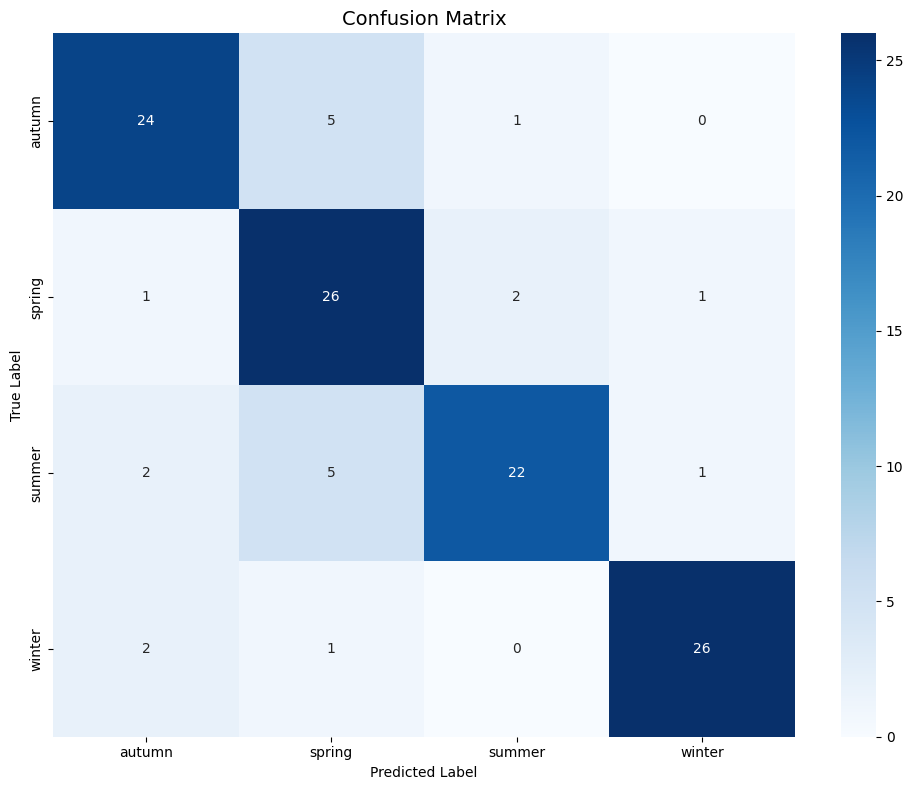

KONAČNI REZULTATI MODELA
Ukupna tačnost: 0.8235 (82.35%)
Preciznost: 0.8339 | Odziv: 0.8235 | F1-score: 0.8248

 Tačno: 98/119
 Netačno: 21/119

 Nasumično pogađanje: 25% | Naš model: 82.4%


In [21]:
viz.visualize_confusion_matrix(test_loader)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Izračunaj metrike
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')


print("KONAČNI REZULTATI MODELA")
print(f"Ukupna tačnost: {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Preciznost: {precision:.4f} | Odziv: {recall:.4f} | F1-score: {f1:.4f}")
print(f"\n Tačno: {sum(1 for t,p in zip(y_true,y_pred) if t==p)}/{len(y_true)}")
print(f" Netačno: {sum(1 for t,p in zip(y_true,y_pred) if t!=p)}/{len(y_true)}")
print(f"\n Nasumično pogađanje: 25% | Naš model: {accuracy*100:.1f}%")

## t-SNE vizuelizacija

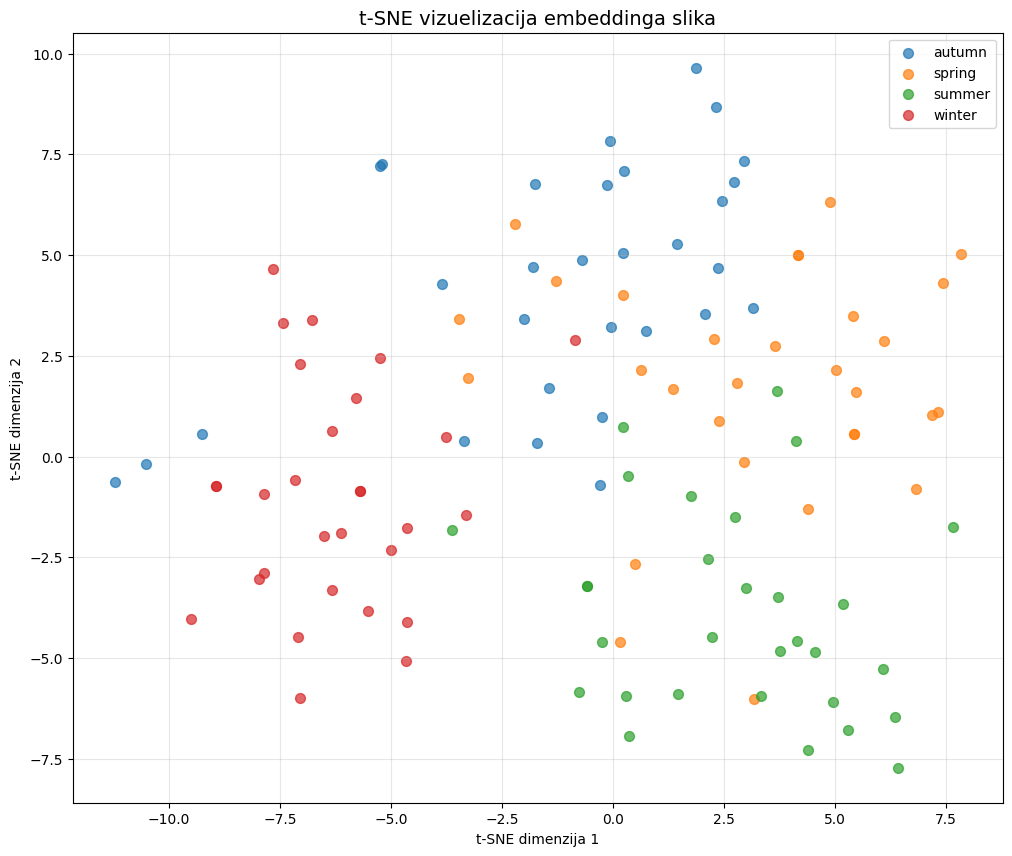

In [22]:
viz.visualize_tsne(test_loader, max_samples=300)

## Interpretacija t-SNE vizuelizacije

t-SNE projekcija feature vektora iz poslednjeg sloja modela pokazuje jasnu strukturu u podacima koja odgovara teoriji sezonskog kolorita.

### 1. Horizontalna osa - Svetlina kože
- **Leva strana**: Autumn i Winter → **tamniji ten**
- **Desna strana**: Spring i Summer → **svetliji ten**

Ovo takođe odgovara teoriji - proleće i leto karakterišu svetliji tonovi kože, dok jesen i zimu odlikuju tamniji tonovi.

### 2. Vertikalna osa - Podton kože
- **Gornji deo**: Autumn i Spring → **topli podton** (žućkasta ili rozikasta koža)
- **Donji deo**: Summer i Winter → **hladni podton** (plavičasta koža)

Ovo je u skladu sa teorijom sezonskog tipa, gde proleće i jesen pripadaju toplim tipovima, a leto i zima hladnim tipovima.

### Zaključak
Model je uspešno naučio dve ključne karakteristike sezonskih boja:
- **Svetlina kože** (svetli vs tamni) - horizontalna osa
- **Podton kože** (topli vs hladni) - vertikalna osa

Rezultati su u skladu sa naučnim istraživanjima o sezonskim bojama, gde se osobe klasifikuju na osnovu kombinacije podtona i svetline kože. Ovo potvrđuje da model ne prepoznaje samo površinske sličnosti, već je naučio konceptualne razlike među sezonama.

Iako se na grafiku mogu uočiti jasno grupisane tačke po sezonama, prisutna su i određena preklapanja, naročito između Spring i Autumn (topli tonovi). Ova ustupanja su očekivana s obzirom na suptilne razlike između ovih sezonskih tipova, što ukazuje na to da problem klasifikacije spada u problem sa nejasnim granicama.

## Pogrešno klasifikovani primeri

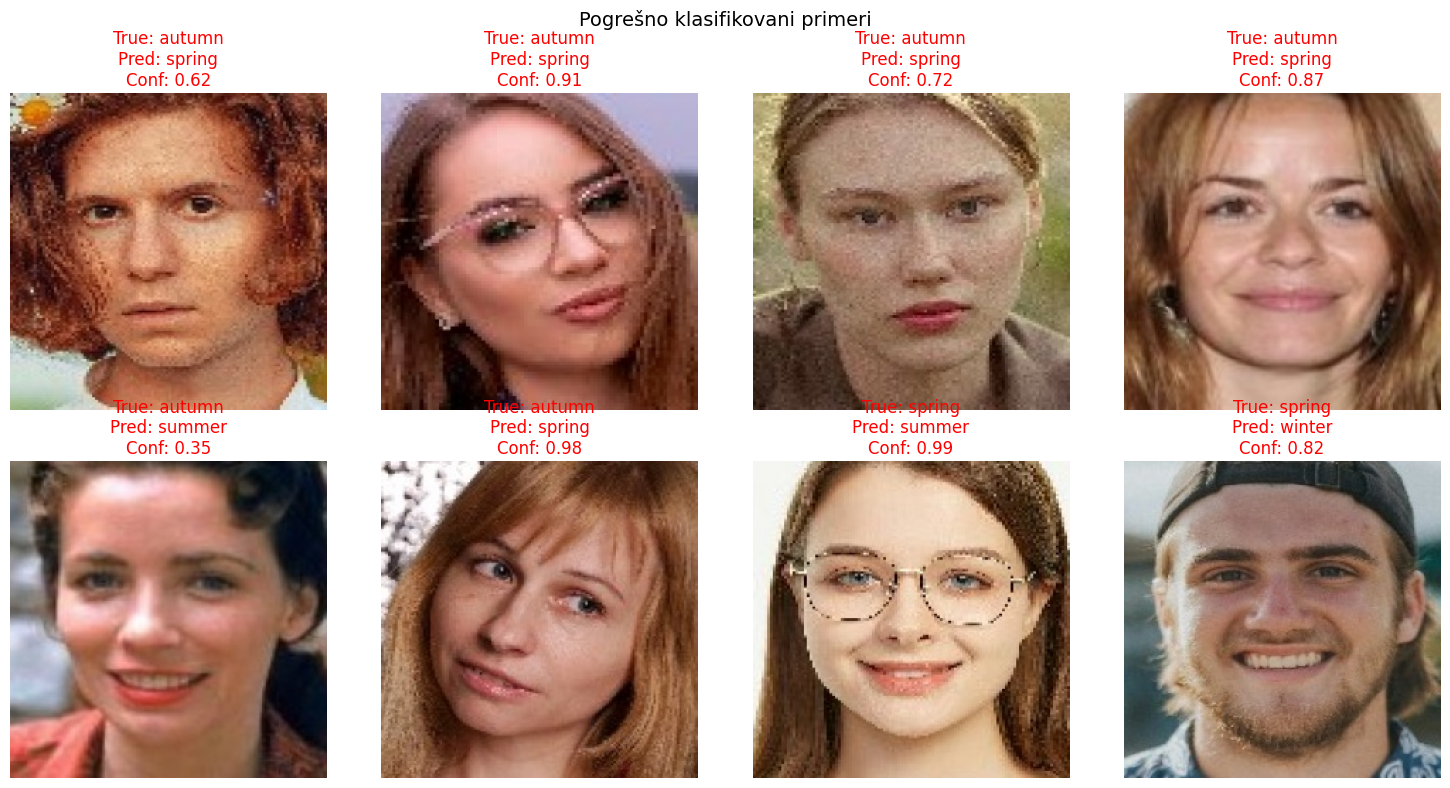

In [23]:
viz.visualize_misclassified(test_loader, num_examples=8)